In [1]:
import gpt as g
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from itertools import permutations

import scipy
import math
from scipy import special as sp
import time

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x308000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize])
    return np.mean(resmpld)

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
def autocorrelation2(samples, separation, max_separation, binsize):
    mean = np.mean(samples)
    ACF = []
    err = []
    t = -1
    nskip = int(0)
    #binsize = 50
    
    for i in range(int(max_separation / separation)):
        t += separation
        temp = []
        
        for i in range(np.size(samples)-t):
            temp.append((samples[i+t] - mean) * (samples[i] - mean))
        
        N2 = np.size(temp)
    
        jk = Jackknife( N2-nskip, binsize )
        jk.set( simple_mean, temp )
        jk.do_it()
        
        ACF.append(np.mean(temp))
        err.append(jk.err())
    
    x = np.arange(1, np.size(ACF))
    for i in x:
        ACF[i] /= ACF[0]
        err[i] /= ACF[0]
        
    err[0] = 0.
    ACF[0] = 1.
    
    
    return ACF, err

In [8]:
size = 4
grid = g.grid([size, size, size, size], g.double)
rng = g.random(str(time.time()))

U = g.qcd.gauge.unit(grid)
#rng.normal_element(U)

#U[0][:]

GPT :      23.218248 s : Initializing gpt.random(1757687630.59611,vectorized_ranlux24_389_64) took 0.00103712 s


In [9]:
action_gauge = g.qcd.gauge.action.wilson(7.0)

metro = g.algorithms.markov.metropolis(rng)
inv = g.algorithms.inverter
sympl = g.algorithms.integrator.symplectic

log = sympl.log()
pure_gauge = True


In [10]:
# thermalize lattice first
beta = g.default.get_float("--beta", 7.0)
seed = g.default.get("--seed", "hmc-pure-gauge")
ntherm = g.default.get_int("--ntherm", 10)
n = g.default.get_int("--n", 200)
nwrite = g.default.get_int("--nwrite", 10)
g.default.set_verbose("omf4")

# conjugate momenta
mom = g.group.cartesian(U)

# Log
g.message(f"Lattice = {grid.fdimensions}")
g.message("Actions:")
# action for conj. momenta
a0 = g.qcd.scalar.action.mass_term()
g.message(f" - {a0.__name__}")

# wilson action 
a1 = g.qcd.gauge.action.wilson(beta)
g.message(f" - {a1.__name__}")
    
    
def hamiltonian():
    return a0(mom) + a1(U) 

# molecular dynamics
sympl = g.algorithms.integrator.symplectic
    
iphmc = sympl.update_p(mom, lambda: a1.gradient(U, U))
iqhmc = sympl.update_q(U, lambda: a0.gradient(mom, mom))

# integrator
mdint_hmc = sympl.leap_frog(50, iphmc, iqhmc)
#g.message(f"Integration scheme:\n{mdint}")
    
# metropolis
metro = g.algorithms.markov.metropolis(rng)
    
# MD units
tau = 1.0
g.message(f"tau = {tau} MD units")

def hmc(tau, mom):
    rng.normal_element(mom)
    accrej = metro(U)
    h0 = hamiltonian()
    mdint_hmc(tau)
    h1 = hamiltonian()
    return [accrej(h1, h0), h1 - h0]


# thermalization
for i in range(1, 20):
    h = []
    timer = g.timer("hmc")
    for _ in range(ntherm // 10):
        timer("trajectory")
        h += [hmc(tau, mom)]
    h = np.array(h)
    timer()
    g.message(f"{i*10} % of thermalization completed")
    g.message(timer)
    g.message(
        f"Plaquette = {g.qcd.gauge.plaquette(U)}, Acceptance = {np.mean(h[:,0]):.2f}, |dH| = {np.mean(np.abs(h[:,1])):.4e}"
    )


start = time.time()

# production
history = []
plaq = []


wf_energyHMC = []
for i in range(50):
    history += [hmc(tau, mom)]
    P = g.qcd.gauge.plaquette(U)
    plaq.append(P)
    g.message(f"Trajectory {i}, P={P}")
    #if i % nwrite == 0:
    #    g.save(f"ckpoint_lat.{seed}.{i}", U, g.format.nersc())

    """
    if i % 5 == 0:
        t = 0.0
        eps = 0.05
        U_wf = g.copy(U)
        
        for i in range(160): # t = 8
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)

        E = g.qcd.gauge.energy_density(U_wf)
        wf_energyHMC.append(E)
    """


end = time.time()
print("time taken = ", end - start)

history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")



GPT :      26.303239 s : Lattice = [4, 4, 4, 4]
GPT :      26.304486 s : Actions:
GPT :      26.305030 s :  - mass_term(m^-1 = 1.0)
GPT :      26.305523 s :  - wilson(7.0)
GPT :      26.306661 s : tau = 1.0 MD units
GPT :      26.707997 s : 10 % of thermalization completed
GPT :      26.708281 s : hmc:
                       : trajectory           4.00e-01 s (= 100.00 %); time/s = 4.00e-01/4.00e-01/4.00e-01 (min/max/avg)
GPT :      26.708642 s : Plaquette = 1.0, Acceptance = 0.00, |dH| = 9.1928e-01
GPT :      27.054578 s : 20 % of thermalization completed
GPT :      27.054831 s : hmc:
                       : trajectory           3.46e-01 s (= 100.00 %); time/s = 3.46e-01/3.46e-01/3.46e-01 (min/max/avg)
GPT :      27.055202 s : Plaquette = 0.8947805344517191, Acceptance = 1.00, |dH| = 9.4159e-01
GPT :      27.400541 s : 30 % of thermalization completed
GPT :      27.400782 s : hmc:
                       : trajectory           3.45e-01 s (= 100.00 %); time/s = 3.45e-01/3.45e-01/3.45e-0

In [25]:
W = g.copy(U)

In [26]:
                                        # domain to be updated. even = False => odd
def freeze_connecting_links(block_size, even = True):
    domain_even = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even)
    domain_odd = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd)

    if even:
        domain_parity = domain_even
    else:
        domain_parity = domain_odd
    
    def find_links_to_freeze(domain_parity):
        vol = block_size ** grid.nd
        links = []

        border_domains = []
        boundary_points = np.array([[0,0,0,0]], dtype=np.int32)
        for i in range(domain_parity.number_of_local_blocks//2 ) :
            domain =  domain_parity.gcoor[ vol*i : vol*(i+1) ] # pick out the coords in adjacent domains
            if np.any(domain[0] == 0) or np.any(domain[-1] == size-1):
                border_domains.append( i )
                boundary_points = np.concatenate(( boundary_points, domain )) # all points in the boundary domains are added 

        x = [1, size-1] + [0 for i in range(grid.nd - 2)]
        perms = np.unique(list(permutations(x)), axis=0)
        
        
        # removing loop over all domains here
        #for j in border_domains:
        j = border_domains[-1]
        domain = domain_parity.gcoor[ vol*j : vol*(j+1) ]
        max_vals = domain[-1]
            
        for k in domain:
            if np.any(k == max_vals): # really only need forward ends
                for l in perms:
                    if (boundary_points == (k + np.asarray(l, dtype=np.int32) ) % size ).all(axis=1).any():
                        #links.append( [(k + np.asarray(l, dtype=np.int32) ) % size, np.where(np.asarray(l) == 1)[0][0], j ])
                        #links.append( [k , np.where(np.asarray(l) == 1)[0][0], j ])
                        # also works with just k
                        links.append( [k , np.where(np.asarray(l) == 1)[0][0]]) # okay this actually makes sense I think
        # actually makes sense that 
        
        #domain
        #for l in links:
        j = border_domains[-1]
        domain = domain_parity.gcoor[ vol*j : vol*(j+1) ]

        domain_entries = []
        for i in range(len(links)):
            #idxs = np.where((A == target).all(axis=1))[0] 
            domain_entries.append( [np.where((domain == links[i][0]).all(axis=1))[0], links[-i][1]] )

        frozen_links = []
        
        for i in range(domain_parity.number_of_local_blocks//2 ) :
            domain =  domain_parity.gcoor[ vol*i : vol*(i+1) ]
            for l in domain_entries:
                frozen_links.append( [domain[l[0]], l[1]])
        
        return frozen_links
        #return links
    
    def freeze_opposite_parity_blocks(even):
        if even:
            return domain_odd.gcoor
        else:
            return domain_even.gcoor

    def link_masks():
        frozen_sites = freeze_opposite_parity_blocks(even)
        frozen_links = find_links_to_freeze(domain_parity)

        mask = g.qcd.gauge.unit(grid)   
        
        for i in frozen_sites:
            for mu in range(grid.nd):
                mask[mu][i] = 0.
    
        for j in frozen_links:
            mask[j[1]][j[0]] = 0.
        
        #return frozen_links
        return mask

    return link_masks()

In [27]:
def coordinate_mask(block_size, even = True):
    vol = block_size ** grid.nd
    
    if even:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even).gcoor
    else:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd).gcoor

    blocks_per_line = size // block_size // 2 # this should still be good (but check here)
    skip = vol * blocks_per_line # need to be careful about the order in which blocks appear in the domain
    
    idx  = np.arange(conjugate_site_locations.shape[0]) 
    mask11 = ((idx // skip) % 2) == 1 # create mask to keep 4, skip 4, keep 4 etc

    coord_mask = conjugate_site_locations[mask11] # apply mask 

    mask = g.qcd.gauge.unit(grid) 
        
    for i in coord_mask:
        for mu in range(grid.nd):
            mask[mu][i] = 0.

    return mask
    
def momentum_mask(block_size, even = True):
    vol = block_size ** grid.nd
    
    if even:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even).gcoor
    else:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd).gcoor

    blocks_per_line = size // block_size // 2
    skip = vol * blocks_per_line
    
    idx  = np.arange(conjugate_site_locations.shape[0])
    mask11 = ((idx // skip) % 2) == 0
    
    mom_mask = conjugate_site_locations[mask11]
    
    mask = g.qcd.gauge.unit(grid)   
        
    for i in mom_mask:
        for mu in range(grid.nd):
            mask[mu][i] = 0.
        
    return mask


In [28]:
def MC_Ham(U):
    return action_gauge(U)

def gauge_force_coord_update(frozen_links, momenta_mask, block_size):
    # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain ; should be done in 2 of 3 directions, and these can al be the same
    for i in [0,1]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, block_size)

    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * momenta_mask[mu]) # also need mask to block the other active domain!!!
    
    #print(V)
    
    x = log(lambda: V , "gauge")()
    
    return x

def gauge_force_mom_update(frozen_links, coordinate_mask, block_size):

     # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain
    for i in [0,1]:
        for mu in range(grid.nd):
            V[mu] = g.cshift(V[mu], i, -block_size)
        
    for mu in range(grid.nd):
        V[mu] @= g(V[mu] * frozen_links[mu] * coordinate_mask[mu])
    
    
    x = log(lambda: V , "gauge")()
    
    return x

block_size4 = 2

even = False
frozen224 = freeze_connecting_links(block_size4, even)
coord_mask4 = coordinate_mask(block_size4, even)
mom_mask4 = momentum_mask(block_size4, even)


iq_14 = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(frozen224, mom_mask4, block_size4), "gauge_force_coord_update")
)

iq_24 = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(frozen224, coord_mask4, block_size4), "gauge_force_mom_update")
)

# integrator
mdint__4 = sympl.leap_frog(40, iq_14, iq_24)

In [29]:

energies2 = [MC_Ham(U)]

for i in range(5):
    #mdint__(tau)
    mdint__4(tau) # something is still wrong
    energies2.append(MC_Ham(U))
    
    print("traj = ", i , "ham = ", energies2[-1])

traj =  0 ham =  3440.7396709253467
traj =  1 ham =  3440.6929784028653
traj =  2 ham =  3440.642432259425
traj =  3 ham =  3440.7273840864273
traj =  4 ham =  3440.6871625873328


In [30]:
block_sizes4 = 4

even = False
frozen22s4 = freeze_connecting_links(block_sizes4, even)
coord_masks4 = coordinate_mask(block_sizes4, even)
mom_masks4 = momentum_mask(block_sizes4, even)


iq_1s4 = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(frozen22s4, mom_masks4, block_sizes4), "gauge_force_coord_update")
)

iq_2s4 = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(frozen22s4, coord_masks4, block_sizes4), "gauge_force_mom_update")
)

# integrator
mdint__s4 = sympl.leap_frog(80, iq_1s4, iq_2s4)

AssertionError: 

In [ ]:
block_sizes2 = 2

even = False
frozen22s2 = freeze_connecting_links(block_sizes2, even)
coord_masks2 = coordinate_mask(block_sizes2, even)
mom_masks2 = momentum_mask(block_sizes2, even)


iq_1s2 = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(frozen22s2, mom_masks2, block_sizes2), "gauge_force_coord_update")
)

iq_2s2 = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(frozen22s2, coord_masks2, block_sizes2), "gauge_force_mom_update")
)

# integrator
mdint__s2 = sympl.leap_frog(80, iq_1s2, iq_2s2)

In [ ]:

energies2 = [MC_Ham(U)]

for i in range(5):
    #mdint__(tau)
    mdint__4(1.5*tau) # something is still wrong
    energies2.append(MC_Ham(U))
    
    print("traj = ", i , "ham = ", energies2[-1])

In [27]:
def MC_run(mdint__, tau):
    V = g.copy(U)
    Ei = MC_Ham(U)
    tau1 = tau * (np.random.randint(0,2)*2 - 1) 
    mdint__2(tau)
    Ef = MC_Ham(U)
    if np.exp(- (Ef - Ei)) < np.random.uniform(0,1):
        for mu in range(4):
            U[mu] @= V[mu]
        print("REJECT", "DELTA S = ", Ef - Ei )
    
        return 0

    else:
        return 1

In [44]:
dwfeMC2 = []
TPQ_mc = []
eps = 0.05

trajectories = 100

ergod = 1
history = 0

for i in range(trajectories):
    if i == 0:
        U_wf = g.copy(U)
        for l in range(80): # t = 4
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
                
    wfi = g.qcd.gauge.energy_density(U_wf)
    Qi = g.qcd.gauge.topological_charge(U_wf)
    
    for k in range(ergod):
        hmc(tau, mom)
        print("HMC ", g.qcd.gauge.plaquette(U))
    
    history += MC_run(mdint__2, tau)
    print("2 even ", "traj = ", i, )
    print("MC ", g.qcd.gauge.plaquette(U))
    history += MC_run(mdint__s2, tau)
    print("2 odd ", "traj = ", i)
    print("MC ", g.qcd.gauge.plaquette(U))
    history += MC_run(mdint__4, tau)
    print("4 even ", "traj = ", i)
    print("MC ", g.qcd.gauge.plaquette(U))
    history += MC_run(mdint__s4, tau)
    print("4 odd ", "traj = ", i)
    print("MC ", g.qcd.gauge.plaquette(U))

    U_wf = g.copy(U)
    for l in range(80): # t = 4
        U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
    wff = g.qcd.gauge.energy_density(U_wf)
    Qf = g.qcd.gauge.topological_charge(U_wf)
    TPQ_mc.append( Qf - Qi )
        
    dwfeMC2.append(wff - wfi)
    

print(history / (trajectories * 4))
    
    

HMC  0.6699643538912073
2 even  traj =  0
MC  0.6699644721211501
2 odd  traj =  0
MC  0.6699645082104952
4 even  traj =  0
MC  0.6699645387474958
4 odd  traj =  0
MC  0.6699640627607591
HMC  0.6690802801124337
2 even  traj =  1
MC  0.6690799856044966
2 odd  traj =  1
MC  0.6690801184758368
4 even  traj =  1
MC  0.6690802321676673
4 odd  traj =  1
MC  0.6690802322562536
HMC  0.6705104734703936
2 even  traj =  2
MC  0.6705102630255592
2 odd  traj =  2
MC  0.6705103566319366
4 even  traj =  2
MC  0.670510508891318
4 odd  traj =  2
MC  0.6705105866247126
HMC  0.6705105866247126
2 even  traj =  3
MC  0.6705107957727593
2 odd  traj =  3
MC  0.6705102984855738
4 even  traj =  3
MC  0.6705104064839844
4 odd  traj =  3
MC  0.6705108491270827
HMC  0.6705108491270827
2 even  traj =  4
MC  0.6705105080062994
2 odd  traj =  4
MC  0.6705107492829346
4 even  traj =  4
MC  0.6705108840117734
4 odd  traj =  4
MC  0.670510852228825
HMC  0.6688372082012398
2 even  traj =  5
MC  0.6688368934224393
2 odd  

/opt/homebrew/Cellar/python-matplotlib/3.10.3/libexec/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/homebrew/Cellar/python-matplotlib/3.10.3/libexec/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


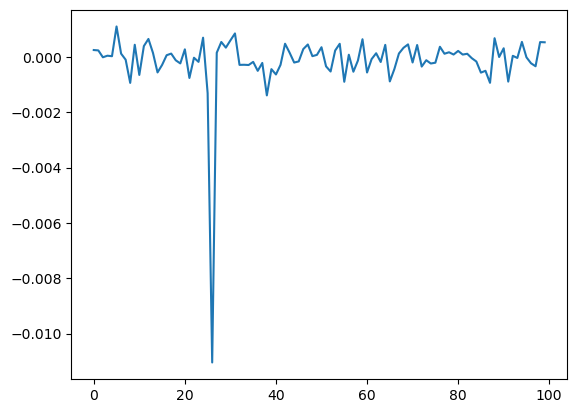

In [46]:
plt.plot(dwfeMC2)

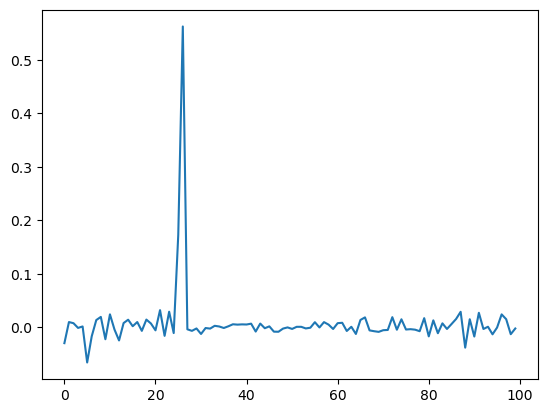

In [47]:
#dwfeMC2
plt.plot(TPQ_mc)

In [49]:
dwfeHMC2 = []
TPQ_hmc = []
eps = 0.05

trajectories = 100

ergod = 1
history = 0

for i in range(trajectories):
    if i == 0:
        U_wf = g.copy(U)
        for l in range(80): # t = 4
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
                
    wfi = g.qcd.gauge.energy_density(U_wf)
    Qi = g.qcd.gauge.topological_charge(U_wf)
    
    for k in range(3):
        hmc(tau, mom)
        print("HMC ", g.qcd.gauge.plaquette(U))

    U_wf = g.copy(U)
    for l in range(80): # t = 4
        U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
    wff = g.qcd.gauge.energy_density(U_wf)
    Qf = g.qcd.gauge.topological_charge(U_wf)
    TPQ_hmc.append( Qf - Qi )
        
    dwfeHMC2.append(wff - wfi)
    print("traj = ", i)

print(history / (trajectories * 4))
    
    

HMC  0.6699926201264744
HMC  0.6709160894861004
HMC  0.6704534949576507
traj =  0
HMC  0.6709987042018336
HMC  0.6692747270955887
HMC  0.6706111894743673
traj =  1
HMC  0.6699062997233924
HMC  0.6711298468390213
HMC  0.6709252365984719
traj =  2
HMC  0.6712935407832078
HMC  0.6712935407832078
HMC  0.6704315890445525
traj =  3
HMC  0.67005314708353
HMC  0.6714337441025994
HMC  0.6719195649642046
traj =  4
HMC  0.6719195649642046
HMC  0.6736989219631234
HMC  0.6748432124493214
traj =  5
HMC  0.6748432124493214
HMC  0.6736794192081628
HMC  0.6730312170366631
traj =  6
HMC  0.671591099922206
HMC  0.6705791574142071
HMC  0.6736095737303889
traj =  7
HMC  0.6736095737303889
HMC  0.6716835187018542
HMC  0.6726002733283568
traj =  8
HMC  0.6720897783583589
HMC  0.6719795639760989
HMC  0.6706340013810008
traj =  9
HMC  0.6723369549866759
HMC  0.6747930868862299
HMC  0.673723116143512
traj =  10
HMC  0.6724443667909479
HMC  0.6696214078249478
HMC  0.6710094234814079
traj =  11
HMC  0.67146090850

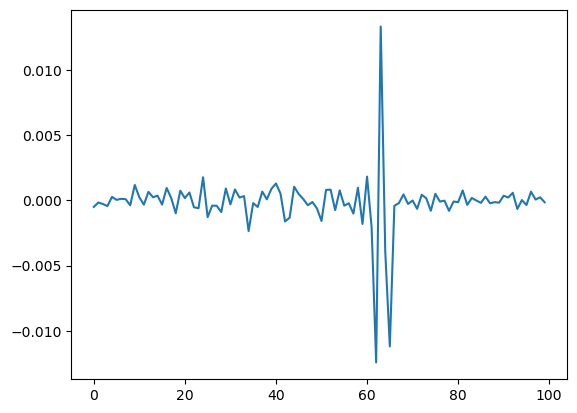

In [51]:
plt.plot(dwfeHMC2)

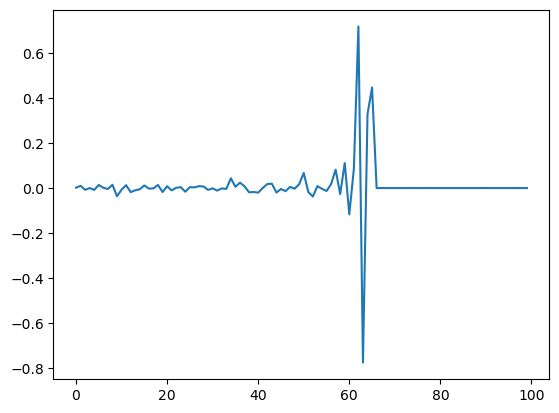

In [55]:
plt.plot(TPQ_hmc)


In [56]:
M = [abs(x) for x in dwfeMC2]
print("MC", np.mean(np.asarray(M)), np.std(np.asarray(M)))

Mhmc = [abs(x) for x in dwfeHMC2]
print("HMC", np.mean(np.asarray(Mhmc)), np.std(np.asarray(Mhmc)))

MC 0.00046493697300664606 0.0011010442654796882
HMC 0.0009452397480607823 0.0020892323771451666


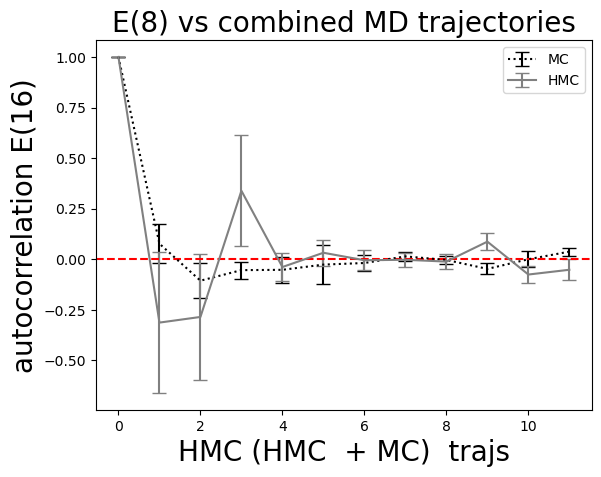

In [59]:
MC = autocorrelation2(dwfeMC2, 1, 12, 1)
HMC = autocorrelation2(dwfeHMC2, 1, 12, 1)


plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation E(16)", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
plt.errorbar(np.arange(len(MC[0])), MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0])), HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.legend()
#plt.savefig("2D_100_E16_AC.pdf")

In [35]:
dwfeMC2 = []
TPQ_mc = []

dwfeHMC2 = []
TPQ_HMC = []
eps = 0.05

tau1 = tau


for j in range(1):
    for i in range(10):
        if i == 0:
            U_wf = g.copy(U)
                        
            for l in range(80): # t = 4
                U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            Q = g.qcd.gauge.topological_charge(U_wf)
            TPQ_mc.append( Q )
        
        Ei = g.qcd.gauge.energy_density(U_wf)

        hmc(tau, mom)
        tau1 *= (np.random.randint(0,2)*2 - 1) 
        mdint__2(3.*tau1)
        tau1 *= (np.random.randint(0,2)*2 - 1) 
        mdint__s2(3.*tau1)
        tau1 *= (np.random.randint(0,2)*2 - 1) 
        mdint__4(3.*tau1)
        tau1 *= (np.random.randint(0,2)*2 - 1) 
        mdint__s4(3.*tau1)
        
        U_wf = g.copy(U)
                    
        for l in range(80): # t = 4
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ef = g.qcd.gauge.energy_density(U_wf)
        Q = g.qcd.gauge.topological_charge(U_wf)
        TPQ_mc.append( Q )
        
        dwfeMC2.append(Ef - Ei)
        print("traj = ", i, "MC delta E  ", dwfeMC2[-1])
        print("traj = ", i, "MC Q  ", TPQ_mc[-1])

    
    Q = g.qcd.gauge.topological_charge(U_wf)
    TPQ_HMC.append( Q )
    
    for i in range(10):
        if i == 0:
            U_wf = g.copy(U)
                        
            for l in range(80): # t = 4
                U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
                
        Ei = g.qcd.gauge.energy_density(U_wf)
        
        
        #mdintMC(tau1)
        for kk in range(5):
            hmc(tau, mom)
        #hmc(tau, mom)
    
        U_wf = g.copy(U)
                    
        for l in range(80): # t = 4
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ef = g.qcd.gauge.energy_density(U_wf)
        Q = g.qcd.gauge.topological_charge(U_wf)
        TPQ_HMC.append( Q )
        
        dwfeHMC2.append(Ef -Ei)
    
        print("traj = ", i, "HMC delta E ", dwfeHMC2[-1])
        print("traj = ", i, "HMC Q ", TPQ_HMC[-1])


traj =  0 MC delta E   (-2.6230477788224483e-05-3.466789979964168e-39j)
traj =  0 MC Q   3.188860613360416e-06
traj =  1 MC delta E   (8.857396727451417e-05+7.102901655969633e-39j)
traj =  1 MC Q   2.7508344730891356e-05
traj =  2 MC delta E   (3.881594951873923e-05-6.279252049802649e-39j)
traj =  2 MC Q   -3.0290838939212435e-06
traj =  3 MC delta E   (-1.3597680366652298e-05-2.8067223513286064e-39j)
traj =  3 MC Q   -1.1649896705161834e-05
traj =  4 MC delta E   (-8.055433401865219e-05+7.863414358527997e-39j)
traj =  4 MC Q   -7.725898913051943e-06
traj =  5 MC delta E   (9.174727588457396e-06-4.7180486151167985e-39j)
traj =  5 MC Q   1.10176050172098e-06
traj =  6 MC delta E   (-0.00014229912166407077-4.2990491638959636e-39j)
traj =  6 MC Q   -1.7028128715151734e-05
traj =  7 MC delta E   (0.00019034476214437827+6.078361901957043e-39j)
traj =  7 MC Q   2.1118705072384236e-05
traj =  8 MC delta E   (1.79779882304974e-05-1.4349296274686127e-40j)
traj =  8 MC Q   -4.928225530292505e-06

In [39]:
M = [abs(x) for x in dwfeMC2]
print("MC", np.mean(np.asarray(M)), np.std(np.asarray(M)))

Mhmc = [abs(x) for x in dwfeHMC2]
print("HMC", np.mean(np.asarray(Mhmc)), np.std(np.asarray(Mhmc)))
# 16

# This doesn't really seem to be a good measure. Will probably need 3 and 4 D then measure topological charge

MC 6.415724765601504e-05 5.7962250626069484e-05
HMC 0.00013730063863810765 0.00010630633550112183


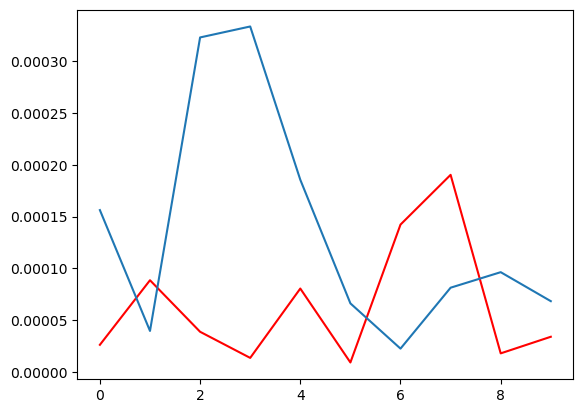

In [40]:
plt.plot(M, color='r')
plt.plot(Mhmc)

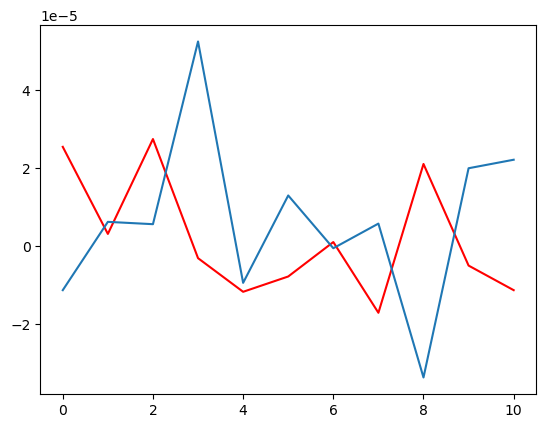

In [41]:
plt.plot(TPQ_mc, color='r')
plt.plot(TPQ_HMC)

In [20]:
# production
history = []
plaqMC = []
wf_energy = []

tau1 = tau*0.5

start = time.time()

ff = 0
for i in range(10):
    for j in range(1):
        history += [hmc(tau, mom)]
        ff += 1
    print("hmc ", g.qcd.gauge.plaquette(U))

    # should mix these in more because swapping directions almost undoes 90 percent of the work
    for k in range(9):
        ff += 1
        en1 = MC_Ham(U)
        V = g.copy(U) # should give wrong asnwer though unless I randomly choose t direction
        if np.random.randint(0,2) == 0:
            tau1 *= -1 # I am just going back and forth!!!
        mdintMC(tau1)
        en2 = MC_Ham(U)
        print("MC ", g.qcd.gauge.plaquette(U))
        if np.exp(- (en2 - en1)) < np.random.uniform(0,1):
            #U[:] @= V[:]
            U[0] @= V[0]
            U[1] @= V[1]
            print("REJECT", "DELTA S = ", en2 - en1 )
        
        if ff % 2 == 0:
            t = 0.0
            eps = 0.05
            U_wf = g.copy(U)
            
            for l in range(320): # t = 8
                U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
    
            E = g.qcd.gauge.energy_density(U_wf)
            wf_energy.append(E)
    
    P = g.qcd.gauge.plaquette(U)
    plaqMC.append(P) 
    
    g.message(f"Trajectory {i}, P={P}")
    #if i % nwrite == 0:
    #    g.save(f"ckpoint_lat.{seed}.{i}", U, g.format.nersc())


end = time.time()
print("time taken = ", end - start)

history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")

hmc  0.6205885276193673
MC  0.6205854478644204
MC  0.6205885276193603
MC  0.6205926043699506
MC  0.6205986396742977
MC  0.6205926043699437
MC  0.6205986396742907
MC  0.6205892657825727
MC  0.620598639674284
MC  0.6205892657825657
GPT :     689.175340 s : Trajectory 0, P=0.6205892657825657
hmc  0.6194502910111447
MC  0.6194502088704802
MC  0.619452532469261
MC  0.6194502088704733
MC  0.6194502910111309
MC  0.6194502088704663
MC  0.619452532469247
MC  0.6194486326696841
MC  0.6194525324692401
MC  0.6194502088704524
GPT :     728.544769 s : Trajectory 1, P=0.6194502088704524
hmc  0.6185654310988362
MC  0.6185593034294534
REJECT DELTA S =  0.2509893379192363
MC  0.6185589455840712
MC  0.6185594496834002
MC  0.6185589455840643
MC  0.6185654310988223
MC  0.6185593034294394
MC  0.6185654310988155
MC  0.6185593034294325
MC  0.6185654310988085
GPT :     767.979203 s : Trajectory 2, P=0.6185654310988085
hmc  0.6143453965247211
MC  0.6143455561600145
MC  0.6143453965247141
MC  0.6143455561600075


10
0.615978223588054
0.0028702249365384703


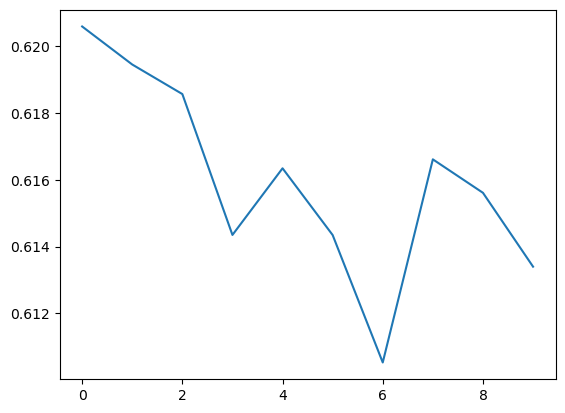

In [22]:
print(len(plaqMC))
print(np.mean(plaqMC))
print(np.std(plaqMC))

plt.plot(plaqMC)

#0.6182843801630405
#0.0018838648675919768

In [26]:
print(len(plaq[0:-1:10]))
print(len(plaq_samp))

10
10


(0.0008500715814509259+1.1879782385812645e-40j)
7.179945409193131e-05


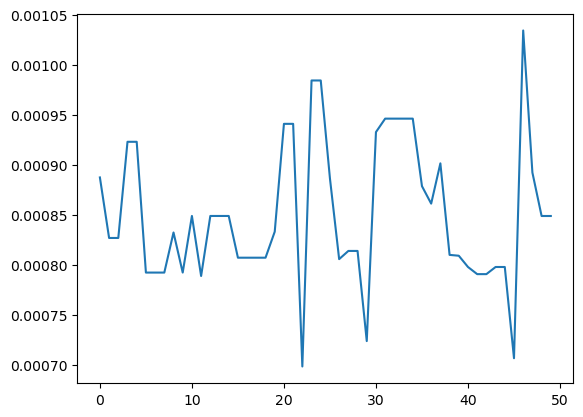

In [27]:
print(np.mean(wf_energy))
print(np.std(wf_energy))
plt.plot(wf_energy)

#(0.0030426871200031885+9.885789940980357e-40j)
#0.00012500012015086935

In [30]:
wf_energy

[np.complex128(0.0008872313025100398-5.022253696140144e-40j),
 np.complex128(0.0008267279846214287+1.2254299018581952e-39j),
 np.complex128(0.0008267279846214271+6.715470656553107e-40j),
 np.complex128(0.0009228670228665051-5.883211472621312e-40j),
 np.complex128(0.0009228670228665082+1.259868212917442e-39j),
 np.complex128(0.000792131530388456-9.126152430700377e-40j),
 np.complex128(0.0007921315303884589-1.4349296274686127e-41j),
 np.complex128(0.0007921315303884551-4.591774807899561e-41j),
 np.complex128(0.0008322018018597889+4.1325973271096045e-40j),
 np.complex128(0.0007921315303884696-5.165746658887006e-40j),
 np.complex128(0.0008487201447109185+6.801566434201224e-40j),
 np.complex128(0.0007887248747292854+1.8941071082585687e-39j),
 np.complex128(0.0008487201447109317-3.4553105429444193e-39j),
 np.complex128(0.0008487201447109255+2.1552643004578562e-39j),
 np.complex128(0.0008487201447109201-5.911910065170684e-40j),
 np.complex128(0.0008070004241501514-7.461634062836786e-41j),
 np

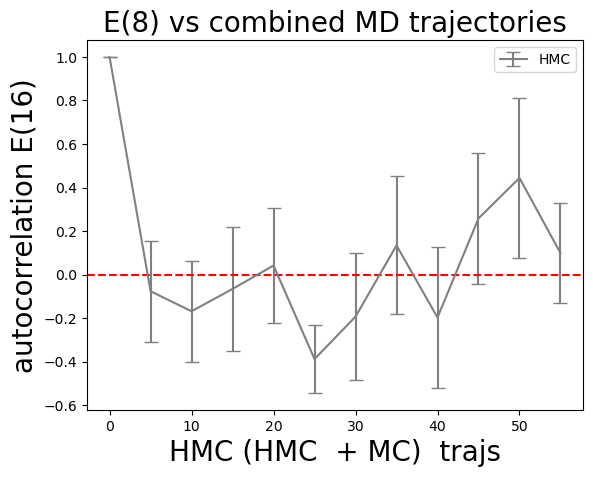

In [75]:
#MC = autocorrelation2(wf_energy, 1, 12, 1)
HMC = autocorrelation2(wf_energyHMC, 1, 12, 1)


plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation E(16)", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
#plt.errorbar(np.arange(len(MC[0]))*2, MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0]))*5, HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.legend()
#plt.savefig("2D_100_E16_AC.pdf")

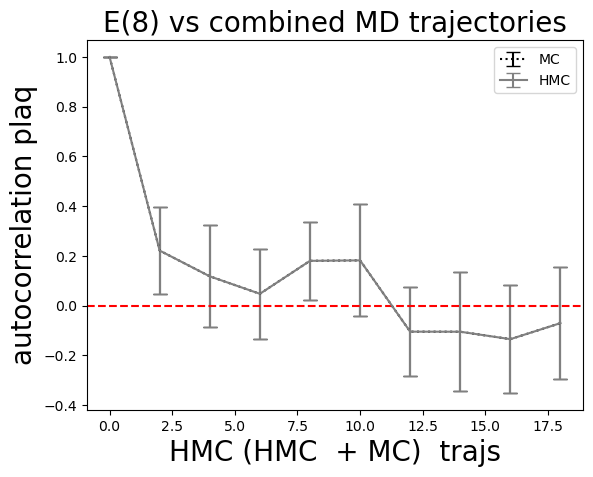

In [95]:
MC = autocorrelation2(plaq[0:-1:10], 1, 10, 1)
HMC = autocorrelation2(plaq_samp, 1, 10, 1)

plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation plaq", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
plt.errorbar(np.arange(len(MC[0]))*2, MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0]))*2, HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.savefig("2D_200_plaq_AC.pdf")
plt.legend()